<a href="https://colab.research.google.com/github/Ololade117/Inducing-Polysemanticity/blob/main/bias_mechanisms_notebook(3.2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing Six Custom Bias Mechanisms in a Character-Level Language Model

This notebook builds **one** architecture whose only difference across six versions
is *how the bias term works* inside each hidden layer. Everything else — embedding
table, weight matrices, the `tanh` nonlinearity, layer count, training loop,
optimizer, random seed — is identical, so any difference in behavior comes from the
bias mechanism alone.

**The six bias types**, all implemented inside `ManualLinear.forward` and picked
with a plain if/else based on a `bias_name` argument passed to the network:

| # | `bias_name` string | What `h = h @ W + b` becomes                                         |
|---|--------------------|-------------------------------------------------------------------------|
| 1 | `gated_sigmoid`    | `h@W + sigmoid(gate) * b` — a learned, sigmoid-squashed gate on `b`      |
| 2 | `gated_relu`       | `h@W + relu(gate) * b` — same idea, ReLU squashing instead               |
| 3 | `gated_tanh`       | `h@W + tanh(gate) * b` — same idea, tanh squashing instead               |
| 4 | `per_position`     | `h@W + b[position]` — a different fixed bias per context slot            |
| 5 | `flex`             | `h@W + (h @ v)` — a bias computed *from the input itself*, one value per row (the "flex bias") |
| 6 | `normal`           | `h@W + b` — the standard, single, fixed bias vector                      |

Every network is still a completely ordinary `nn.Module`: every weight, bias, gate
and flex-vector is a real `nn.Parameter`, held inside an `nn.ModuleList`. So
`model.parameters()`, `print(model)`, `model.state_dict()`, and
`model.layers[i].bias` all work exactly as they would for any built-in PyTorch
layer — the point of the whole exercise is to change the bias mechanism *without*
losing the ability to inspect the network normally.

**Task**: a character-level language model trained on the ~1.1M-character *Tiny
Shakespeare* corpus (the dataset behind Karpathy's char-rnn and nanoGPT). Unlike a
list of independent names, this is **one continuous stream of text** — there's no
per-example start/end token, so the model just slides a `BLOCK_SIZE`-character
window along the whole corpus and predicts whatever character comes next.

**Requirements**: a free [Hugging Face](https://huggingface.co) account with a
write-access token, to run the `push_to_hub` cells. Set `PUSH_TO_HUB = False` in
the setup cell if you just want to run everything else first.

**Notebook layout**
1. Setup
2. Data
3. Shared architecture (all six bias types defined once)
4. Inspecting the architecture *before* training anything
5. Shared training / evaluation / generation helpers
6–11. Six sections, one per bias type: build → train → inspect → push to Hugging Face
12. Side-by-side comparison of all six


## 0. Setup

In [1]:
# If a package is missing, uncomment and run:
# !pip install -q torch huggingface_hub matplotlib

import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from huggingface_hub import PyTorchModelHubMixin, notebook_login

torch.manual_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

HF_USERNAME = "Ololade117"   # <-- replace with your Hugging Face username
PUSH_TO_HUB = True                 # set False to skip the upload steps while testing

# Run this once, then paste a Hugging Face token with write access when prompted.
# notebook_login()


Using device: cuda


## 1. Data

*Tiny Shakespeare*: ~1.1M characters of continuous text, no per-example
boundaries. There's no `.` start/end token here — the model just conditions on
whatever `BLOCK_SIZE` tokens happen to precede a position, anywhere in the
corpus, and predicts the next one.

A handful of near-singleton characters (occurring 1–27 times total — mostly
formatting artifacts, not real dialogue) are dropped before tokenizing; see the
cell below for exactly which ones and why.

The train/val/test split is a **contiguous** slice of the raw text (first 80% /
next 10% / last 10%), not a random shuffle of windows — shuffling overlapping
windows would leak train-set text into the dev/test sets almost verbatim. The
split happens on raw text, *before* tokenizing, so the tokenizer itself is
trained only on `train_text` -- no held-out text leaks into its vocabulary.


In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode("utf-8")
print(f"{len(text):,} characters, e.g.:\n{text[:200]!r}")

# Drop near-singleton characters: a handful of formatting/typo artifacts (a
# stray scene-heading digit, a lone '$', three '&'s) rather than let a few
# classes into the vocab that appear 1-27 times across 1.1M characters and
# can never be learned -- they'd just be dead weight in the output layer.
MIN_CHAR_COUNT = 30
counts = Counter(text)
dropped = {ch for ch, n in counts.items() if n < MIN_CHAR_COUNT}
if dropped:
    print(f"\nDropping {len(dropped)} near-singleton characters {sorted(dropped)!r} "
          f"({sum(counts[c] for c in dropped)} occurrences out of {len(text):,})")
    text = "".join(ch for ch in text if ch not in dropped)

n1 = int(0.8 * len(text))
n2 = int(0.9 * len(text))
train_text, val_text, test_text = text[:n1], text[n1:n2], text[n2:]
print("train/val/test characters:", len(train_text), len(val_text), len(test_text))


1,115,394 characters, e.g.:
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you'

Dropping 3 near-singleton characters ['$', '&', '3'] (31 occurrences out of 1,115,394)
train/val/test characters: 892290 111536 111537


## 1b. A byte-pair-encoding (BPE) tokenizer, from scratch

Character-level modeling puts a hard ceiling on what the model can represent:
every "token" is a single letter, so the model has to keep re-deriving common
clusters (`"th"`, `"ing"`, `" the"`) from scratch at every position instead of
treating them as a unit. BPE fixes this by learning a vocabulary of
frequently-occurring byte sequences directly from the data.

**The algorithm** (the same core idea behind GPT-2/GPT-4's tokenizers, minus
the regex pre-splitting and special-token handling real ones add on top):
1. Start from the 256 raw byte values as the base vocabulary.
2. Count every adjacent pair of tokens in the training text.
3. Merge the single most frequent pair into one new token.
4. Repeat until the vocabulary reaches the target size.

Training here is a full O(merges x text length) recount at every step -- simple
to read, and still only a one-time cost of well under a minute for this corpus
and vocab size. Encoding new text is much cheaper: once the merges are learned,
encoding just replays them in the order they were learned, with no counting.


In [3]:
class BPETokenizer:
    """
    Minimal byte-level BPE tokenizer, trained from scratch on a text corpus --
    the same core algorithm behind GPT-2/GPT-4's tokenizers, without any of
    the regex pre-splitting or special-token handling real ones add on top.
    """

    def __init__(self):
        self.merges = {}                                  # (id1, id2) -> new_id, in learn order
        self.vocab = {i: bytes([i]) for i in range(256)}   # id -> raw bytes

    @property
    def vocab_size(self):
        return len(self.vocab)

    @staticmethod
    def _pair_counts(ids):
        counts = {}
        for a, b in zip(ids, ids[1:]):
            counts[(a, b)] = counts.get((a, b), 0) + 1
        return counts

    @staticmethod
    def _merge(ids, pair, new_id):
        new_ids = []
        i, n = 0, len(ids)
        while i < n:
            if i < n - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids

    def train(self, text, vocab_size, verbose=False):
        assert vocab_size >= 256, "vocab_size must cover at least the raw byte values"
        ids = list(text.encode("utf-8"))
        num_merges = vocab_size - 256
        for i in range(num_merges):
            counts = self._pair_counts(ids)
            if not counts:
                break
            pair = max(counts, key=counts.get)
            new_id = 256 + i
            ids = self._merge(ids, pair, new_id)
            self.merges[pair] = new_id
            self.vocab[new_id] = self.vocab[pair[0]] + self.vocab[pair[1]]
            if verbose and (i + 1) % 32 == 0:
                print(f"  merge {i+1:4d}/{num_merges}: {pair} -> {new_id}  "
                      f"{self.vocab[new_id]!r}  (count {counts[pair]})")

    def encode(self, text):
        ids = list(text.encode("utf-8"))
        for pair, new_id in self.merges.items():  # replay merges in the order learned
            ids = self._merge(ids, pair, new_id)
        return ids

    def decode(self, ids):
        raw = b"".join(self.vocab[i] for i in ids)
        return raw.decode("utf-8", errors="replace")


TOKENIZER_VOCAB_SIZE = 384  # 256 base bytes + 128 learned merges

tokenizer = BPETokenizer()
tokenizer.train(train_text, vocab_size=TOKENIZER_VOCAB_SIZE, verbose=True)

train_data = torch.tensor(tokenizer.encode(train_text), dtype=torch.long)
val_data = torch.tensor(tokenizer.encode(val_text), dtype=torch.long)
test_data = torch.tensor(tokenizer.encode(test_text), dtype=torch.long)
VOCAB_SIZE = tokenizer.vocab_size

print(f"\nvocab_size = {VOCAB_SIZE} (256 base bytes + {len(tokenizer.merges)} merges)")
print(f"train/val/test tokens: {len(train_data):,} / {len(val_data):,} / {len(test_data):,}")
print(f"compression: {len(train_text) / len(train_data):.2f} characters per token")

print("\nA few learned merges, decoded:")
for pair, new_id in list(tokenizer.merges.items())[:8]:
    print(f"  {pair} -> {new_id}  {tokenizer.vocab[new_id]!r}")


  merge   32/128: (266, 260) -> 287  b'and '  (count 3136)
  merge   64/128: (97, 116) -> 319  b'at'  (count 1560)
  merge   96/128: (121, 261) -> 351  b'y, '  (count 1032)
  merge  128/128: (109, 256) -> 383  b'me '  (count 842)

vocab_size = 384 (256 base bytes + 128 merges)
train/val/test tokens: 524,129 / 66,130 / 66,379
compression: 1.70 characters per token

A few learned merges, decoded:
  (101, 32) -> 256  b'e '
  (116, 104) -> 257  b'th'
  (116, 32) -> 258  b't '
  (115, 32) -> 259  b's '
  (100, 32) -> 260  b'd '
  (44, 32) -> 261  b', '
  (111, 117) -> 262  b'ou'
  (101, 114) -> 263  b'er'


### A quick round-trip check

`decode(encode(x))` should reproduce `x` exactly -- worth confirming once,
since a silent tokenizer bug would quietly corrupt every model trained after it.


In [4]:
sample = val_text[1000:1200]
roundtrip = tokenizer.decode(tokenizer.encode(sample))
assert roundtrip == sample, "tokenizer round-trip failed -- stop and debug this before training"
print("OK: decode(encode(x)) == x")
print(repr(sample[:80]))


OK: decode(encode(x)) == x
'te,\nWill so your accusation overweigh,\nThat you shall stifle in your own report\n'


## 2. Shared architecture

`ManualLinear` is the one place `h = h @ W + b` lives. Every bias type is defined
here, chosen with an if/else on `bias_type`. `NormalBiasNet` stacks `ManualLinear`
layers and exposes a single `bias_name` argument that picks which bias mechanism
every hidden layer in that network uses (renamed from a plain `name` to avoid
colliding with `PyTorchModelHubMixin`'s own config/kwarg handling, which silently
swallowed a kwarg called `name` and always fell back to `"normal"`).

Inheriting from `PyTorchModelHubMixin` (in addition to `nn.Module`) is what gives
every model `.push_to_hub(...)`, `.save_pretrained(...)`, and `.from_pretrained(...)`
for free, later in this notebook.


In [5]:
class ManualLinear(nn.Module):
    """
    One h = h @ W + b step. `bias_type` selects which of the six bias
    mechanisms this layer uses -- every mechanism is defined right here.
    """

    def __init__(self, in_dim, out_dim, bias_type="normal", block_size=None):
        super().__init__()
        self.bias_type = bias_type
        self.weight = nn.Parameter(torch.randn(in_dim, out_dim) * in_dim ** -0.5)

        if bias_type == "normal":
            self.bias = nn.Parameter(torch.zeros(out_dim))

        elif bias_type in ("gated_sigmoid", "gated_relu", "gated_tanh"):
            self.bias = nn.Parameter(torch.zeros(out_dim))
            self.gate_param = nn.Parameter(torch.zeros(out_dim))  # learned, pre-activation

        elif bias_type == "per_position":
            assert block_size is not None, "per_position bias needs block_size"
            self.bias = nn.Parameter(torch.zeros(block_size, out_dim))

        elif bias_type == "flex":
            # maps h itself down to one scalar per row (per example, per position)
            self.flex_vec = nn.Parameter(torch.zeros(in_dim, 1))

        else:
            raise ValueError(f"Unknown bias_type: {bias_type!r}")

    def forward(self, h):
        out = h @ self.weight

        if self.bias_type == "normal":
            return out + self.bias

        elif self.bias_type == "gated_sigmoid":
            return out + torch.sigmoid(self.gate_param) * self.bias

        elif self.bias_type == "gated_relu":
            return out + torch.relu(self.gate_param) * self.bias

        elif self.bias_type == "gated_tanh":
            return out + torch.tanh(self.gate_param) * self.bias

        elif self.bias_type == "per_position":
            # self.bias: (block_size, out_dim) broadcasts over the batch dim
            return out + self.bias

        elif self.bias_type == "flex":
            flex_bias = h @ self.flex_vec  # (..., 1) -- one value per row
            return out + flex_bias

        else:
            raise ValueError(f"Unknown bias_type: {self.bias_type!r}")


class NormalBiasNet(
    nn.Module,
    PyTorchModelHubMixin,
    license="mit",
):
    """
    A standard nn.Module. `bias_name` picks the bias mechanism used by every hidden
    layer (see ManualLinear above) -- it's the only thing that changes between
    the six networks built later in this notebook.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, block_size, n_layers=3, bias_name="normal"):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.block_size = block_size
        self.n_layers = n_layers
        self.bias_name = bias_name  # bias type used by every hidden layer in this model

        self.C = nn.Parameter(torch.randn(vocab_size, embed_dim))

        layers = []
        in_dim = embed_dim
        for _ in range(n_layers):
            layers.append(ManualLinear(in_dim, hidden_dim, bias_type=bias_name, block_size=block_size))
            in_dim = hidden_dim
        self.layers = nn.ModuleList(layers)

        # The output head always uses a plain bias: the six-way comparison is
        # about the *hidden* layers, so the head stays fixed across all of them.
        self.out = ManualLinear(hidden_dim * block_size, vocab_size, bias_type="normal")

    def forward(self, X):
        emb = self.C[X]                          # (batch, block_size, embed_dim)

        h = emb
        for layer in self.layers:
            h = torch.tanh(layer(h))              # (batch, block_size, hidden_dim)

        h = h.reshape(h.shape[0], -1)             # (batch, block_size * hidden_dim)
        logits = self.out(h)                      # raw logits -- loss fn applies softmax
        return logits


# Shared hyperparameters -- identical for all six models below, so the *only*
# thing that differs between them is the bias mechanism. BLOCK_SIZE is now
# counted in *tokens*, not characters -- at ~1.7 chars/token, 8 tokens covers
# roughly the same span of text as BLOCK_SIZE=16 did at the character level.
# HIDDEN_DIM comes down a bit from the character-level run because the output
# layer scales with vocab_size, and vocab_size just went from 62 to 384.
BLOCK_SIZE = 8
EMBED_DIM = 48
HIDDEN_DIM = 256
N_LAYERS = 4
STEPS = 20000
BATCH_SIZE = 256
LR = 2e-3


## 3. Inspecting the architecture, before training anything

This is the whole point of building it this way: even with a fully custom bias
mechanism, it's still an ordinary, inspectable `nn.Module`.


In [6]:
demo = NormalBiasNet(vocab_size=VOCAB_SIZE, embed_dim=8, hidden_dim=16,
                      block_size=BLOCK_SIZE, n_layers=2, bias_name="gated_sigmoid")
print(demo)

print("\nParameter shapes:")
for pname, p in demo.named_parameters():
    print(f"  {pname:20s} {tuple(p.shape)}")
print(f"\nTotal parameters: {sum(p.numel() for p in demo.parameters()):,}")

print("\nDirect access to one layer's pieces:")
print("  demo.layers[0].weight.shape ->", demo.layers[0].weight.shape)
print("  demo.layers[0].bias.shape   ->", demo.layers[0].bias.shape)
print("  demo.layers[0].gate_param   ->", demo.layers[0].gate_param)

# Sanity check: confirm the requested bias type actually made it into the
# layers. If this fails, `bias_name` isn't reaching ManualLinear and every
# model will silently train as "normal" regardless of what you asked for.
assert demo.bias_name == "gated_sigmoid", f"expected 'gated_sigmoid', got {demo.bias_name!r}"
assert demo.layers[0].bias_type == "gated_sigmoid", f"expected 'gated_sigmoid', got {demo.layers[0].bias_type!r}"
assert hasattr(demo.layers[0], "gate_param"), "gate_param missing -- this layer did not build as gated_sigmoid"
print("\nOK: bias_name correctly reached every layer's bias_type.")

del demo


NormalBiasNet(
  (layers): ModuleList(
    (0-1): 2 x ManualLinear()
  )
  (out): ManualLinear()
)

Parameter shapes:
  C                    (384, 8)
  layers.0.weight      (8, 16)
  layers.0.bias        (16,)
  layers.0.gate_param  (16,)
  layers.1.weight      (16, 16)
  layers.1.bias        (16,)
  layers.1.gate_param  (16,)
  out.weight           (128, 384)
  out.bias             (384,)

Total parameters: 53,056

Direct access to one layer's pieces:
  demo.layers[0].weight.shape -> torch.Size([8, 16])
  demo.layers[0].bias.shape   -> torch.Size([16])
  demo.layers[0].gate_param   -> Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

OK: bias_name correctly reached every layer's bias_type.


## 4. Shared training / evaluation / generation helpers

Defined once and reused by all six sections below, so each section stays focused
on "build this one model, train it, look at it, push it" instead of repeating a
70-line training loop six times.

`get_batch` replaces the old per-name windowing: since the text is one
continuous stream, each training step just samples random start positions and
slices out `BLOCK_SIZE`-character windows on the fly. `estimate_loss` averages
over several such random batches from `val_data` for a stable loss estimate,
since there's no fixed, pre-built validation set anymore.


In [7]:
trained_models = {}
histories = {}


def get_batch(data, block_size=BLOCK_SIZE, batch_size=BATCH_SIZE):
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    idx = ix.unsqueeze(1) + torch.arange(block_size)  # (batch_size, block_size)
    X = data[idx]
    Y = data[ix + block_size]
    return X, Y


@torch.no_grad()
def estimate_loss(model, data, eval_iters=50):
    model.eval()
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        Xb, Yb = get_batch(data)
        logits = model(Xb.to(DEVICE))
        losses[k] = F.cross_entropy(logits, Yb.to(DEVICE)).item()
    model.train()
    return losses.mean().item()


def train_model(model, steps=STEPS, batch_size=BATCH_SIZE, lr=LR, log_every=2000):
    model.to(DEVICE)
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(steps // 3, 1), gamma=0.3)

    history = {"step": [], "train_loss": [], "dev_loss": []}
    for step in range(1, steps + 1):
        Xb, Yb = get_batch(train_data, batch_size=batch_size)
        Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)

        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        # manually-initialized nets can spike early; this keeps all six comparable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if step % log_every == 0 or step == 1:
            dev_loss = estimate_loss(model, val_data)
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["dev_loss"].append(dev_loss)
            print(f"step {step:5d} | train {loss.item():.3f} | dev {dev_loss:.3f}")

    return history


@torch.no_grad()
def generate(model, prompt="ROMEO:", length=200, block_size=BLOCK_SIZE):
    '''length is in TOKENS now, not characters -- with ~1.7 chars/token that's
    roughly length*1.7 characters of generated text.'''
    model.eval()
    pad_id = 32  # ASCII space -- always present as one of the 256 base byte tokens
    ids = tokenizer.encode(prompt)
    if len(ids) < block_size:
        ids = [pad_id] * (block_size - len(ids)) + ids  # left-pad short prompts
    context = ids[-block_size:]

    generated = list(ids)
    for _ in range(length):
        x = torch.tensor([context]).to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1).item()
        generated.append(ix)
        context = context[1:] + [ix]

    model.train()
    return tokenizer.decode(generated)


def push(model, bias_type):
    repo_id = f"{HF_USERNAME}/shakespeare-bias-{bias_type.replace('_', '-')}"
    if PUSH_TO_HUB:
        model.push_to_hub(repo_id)
        print(f"Pushed to https://huggingface.co/{repo_id}")
    else:
        print(f"PUSH_TO_HUB is False -- skipping upload to {repo_id}")


## Section 1/6 — Gated Sigmoid Bias

The bias is scaled by a learned, per-unit `sigmoid(gate)` in (0, 1) -- the "how open is this gate" mechanism used in LSTMs, GRUs and GLU. `gate_param` starts at 0, so the gate starts half-open (`sigmoid(0) = 0.5`).

In [8]:
BIAS_TYPE = "gated_sigmoid"

torch.manual_seed(42)
model_gated_sigmoid = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_sigmoid.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_sigmoid.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_sigmoid)
print(f"parameters: {sum(p.numel() for p in model_gated_sigmoid.parameters()):,}")

history_gated_sigmoid = train_model(model_gated_sigmoid)

print("\nSample continuation:\n" + generate(model_gated_sigmoid, prompt="ROMEO:", length=200))

trained_models[BIAS_TYPE] = model_gated_sigmoid
histories[BIAS_TYPE] = history_gated_sigmoid


NormalBiasNet(
  (layers): ModuleList(
    (0-3): 4 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 1,016,192
step     1 | train 6.009 | dev 5.917
step  2000 | train 3.413 | dev 3.641
step  4000 | train 3.026 | dev 3.591
step  6000 | train 3.226 | dev 3.602
step  8000 | train 2.760 | dev 3.261
step 10000 | train 2.883 | dev 3.247
step 12000 | train 3.034 | dev 3.227
step 14000 | train 2.878 | dev 3.197
step 16000 | train 2.770 | dev 3.177
step 18000 | train 2.593 | dev 3.185
step 20000 | train 2.617 | dev 3.185

Sample continuation:
  ROMEO: O, this your clament,
Is h the dessin be of their tosicrus to be spost,
En firmue, Inmye,
Of then my bloopry one,
Whench, as come the thy ment:
And there, though tell me, when her fot of hervion King Lord MENENIUS:
You morid sudone the gaint's rook an ggevaunds, but aysequick, as frothers
make your suitt,
Then throw our joy yourdibess not,
I rejure 


In [9]:
push(model_gated_sigmoid, "gated_sigmoid")


No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-gated-sigmoid


## Section 2/6 — Gated ReLU Bias

Same static-gate idea, but squashed with `relu` instead of `sigmoid`. Unlike sigmoid and tanh, this gate is **not bounded above** -- it starts fully closed (`relu(0) = 0`) but nothing stops it growing arbitrarily large during training. Watch the dev-loss curve for any instability this causes; gradient clipping is there to contain it.

In [10]:
BIAS_TYPE = "gated_relu"

torch.manual_seed(42)
model_gated_relu = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_relu.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_relu.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_relu)
print(f"parameters: {sum(p.numel() for p in model_gated_relu.parameters()):,}")

history_gated_relu = train_model(model_gated_relu)

print("\nSample continuation:\n" + generate(model_gated_relu, prompt="ROMEO:", length=200))

trained_models[BIAS_TYPE] = model_gated_relu
histories[BIAS_TYPE] = history_gated_relu


NormalBiasNet(
  (layers): ModuleList(
    (0-3): 4 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 1,016,192
step     1 | train 6.009 | dev 5.919
step  2000 | train 3.442 | dev 3.640
step  4000 | train 3.077 | dev 3.595
step  6000 | train 3.189 | dev 3.596
step  8000 | train 2.757 | dev 3.262
step 10000 | train 2.870 | dev 3.249
step 12000 | train 3.027 | dev 3.225
step 14000 | train 2.883 | dev 3.199
step 16000 | train 2.776 | dev 3.180
step 18000 | train 2.593 | dev 3.186
step 20000 | train 2.611 | dev 3.189

Sample continuation:
  ROMEO: O, this your clament,
Fear mue not sin be bite; for him that his meme.
You tway, firrathion parde,
Of then my bloop you,
Could not soarcom, the arrmen:
And there, thoughtte.
Wew by thatet this hall burnews to speaken for your ffidercan, hear tim. Thure mpry once unns, but aysequick, as frother sause.

BENVOLANAT:
To wore drureblee; whid jue 


In [11]:
push(model_gated_relu, "gated_relu")


No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-gated-relu


## Section 3/6 — Gated Tanh Bias

Same static-gate idea again, squashed with `tanh` this time, so the gate can range over (-1, 1) -- meaning it can *subtract* the bias, not just scale it down. Starts fully closed (`tanh(0) = 0`).

In [12]:
BIAS_TYPE = "gated_tanh"

torch.manual_seed(42)
model_gated_tanh = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_tanh.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_tanh.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_tanh)
print(f"parameters: {sum(p.numel() for p in model_gated_tanh.parameters()):,}")

history_gated_tanh = train_model(model_gated_tanh)

print("\nSample continuation:\n" + generate(model_gated_tanh, prompt="ROMEO:", length=200))

trained_models[BIAS_TYPE] = model_gated_tanh
histories[BIAS_TYPE] = history_gated_tanh


NormalBiasNet(
  (layers): ModuleList(
    (0-3): 4 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 1,016,192
step     1 | train 6.009 | dev 5.919
step  2000 | train 3.442 | dev 3.640
step  4000 | train 3.077 | dev 3.595
step  6000 | train 3.189 | dev 3.596
step  8000 | train 2.757 | dev 3.262
step 10000 | train 2.870 | dev 3.249
step 12000 | train 3.027 | dev 3.225
step 14000 | train 2.883 | dev 3.199
step 16000 | train 2.776 | dev 3.180
step 18000 | train 2.593 | dev 3.186
step 20000 | train 2.611 | dev 3.189

Sample continuation:
  ROMEO: O, this your clament,
Fear mue not sin be bite; for him that his meme.
You tway, firrathion parde,
Of then my bloop you,
Could not soarcom, the arrmen:
And there, thoughtte.
Wew by thatet this hall burnews to speaken for your ffidercan, hear tim. Thure mpry once unns, but aysequick, as frother sause.

BENVOLANAT:
To wore drureblee; whid jue 


In [13]:
push(model_gated_tanh, "gated_tanh")


No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-gated-tanh


## Section 4/6 — Per-Position Bias

Instead of one bias vector shared by every position in the context window, each of the `BLOCK_SIZE` context slots gets its own learned bias -- closer to a positional embedding baked directly into the bias term.

In [14]:
BIAS_TYPE = "per_position"

torch.manual_seed(42)
model_per_position = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_per_position.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_per_position.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_per_position)
print(f"parameters: {sum(p.numel() for p in model_per_position.parameters()):,}")

history_per_position = train_model(model_per_position)

print("\nSample continuation:\n" + generate(model_per_position, prompt="ROMEO:", length=200))

trained_models[BIAS_TYPE] = model_per_position
histories[BIAS_TYPE] = history_per_position


NormalBiasNet(
  (layers): ModuleList(
    (0-3): 4 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 1,022,336
step     1 | train 6.009 | dev 5.908
step  2000 | train 3.380 | dev 3.621
step  4000 | train 2.980 | dev 3.561
step  6000 | train 3.246 | dev 3.590
step  8000 | train 2.797 | dev 3.231
step 10000 | train 2.917 | dev 3.224
step 12000 | train 3.054 | dev 3.211
step 14000 | train 2.873 | dev 3.184
step 16000 | train 2.756 | dev 3.162
step 18000 | train 2.589 | dev 3.177
step 20000 | train 2.627 | dev 3.172

Sample continuation:
  ROMEO: O, th your common,
From the hower in be astrue, sirs hose done's fiom hat
With me shade?
That you me crown, is is pratternts thee, arce, and the Grunt of You stly.

KING EDWARD IV:
Besh, shie; My tearthen for your ffidercan, it set un realy of thin a mon;
Whose deir, that I part of my chans
make praceiving bornow; for this greadonby watifid the laim


In [15]:
push(model_per_position, "per_position")


No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-per-position


## Section 5/6 — Flex Bias

Instead of a fixed, learned vector, the bias is *computed from the input itself*: `h @ v` maps each row of `h` down to a single scalar, so every example (and every position) gets its own bias value depending on its own content, rather than everyone sharing the same fixed vector.

In [16]:
BIAS_TYPE = "flex"

torch.manual_seed(42)
model_flex = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_flex.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_flex.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_flex)
print(f"parameters: {sum(p.numel() for p in model_flex.parameters()):,}")

history_flex = train_model(model_flex)

print("\nSample continuation:\n" + generate(model_flex, prompt="ROMEO:", length=200))

trained_models[BIAS_TYPE] = model_flex
histories[BIAS_TYPE] = history_flex


NormalBiasNet(
  (layers): ModuleList(
    (0-3): 4 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 1,014,960
step     1 | train 6.009 | dev 5.920
step  2000 | train 3.513 | dev 3.667
step  4000 | train 3.076 | dev 3.624
step  6000 | train 3.269 | dev 3.641
step  8000 | train 2.758 | dev 3.280
step 10000 | train 2.888 | dev 3.254
step 12000 | train 3.023 | dev 3.234
step 14000 | train 2.880 | dev 3.201
step 16000 | train 2.786 | dev 3.185
step 18000 | train 2.591 | dev 3.193
step 20000 | train 2.620 | dev 3.192

Sample continuation:
  ROMEO: O, this your clament,
From the hown King of they will do but I will, sposting
What furdere, of me, foly--I
Than know'st madst my sovey:
Whichmigh shair did teulbless;
I'll not ake you that  Parlies timagling namifles,
He the ga tray?

Thurse:
Mese marrias, but ayse,
Got unto the cans
make pricedland
Aranishim that our within I death,
I rejure 


In [17]:
push(model_flex, "flex")


No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-flex


## Section 6/6 — Normal Bias

The baseline: one fixed, learned bias vector, identical for every input -- exactly what `nn.Linear` gives you for free. This is the control condition the other five are being compared against.

In [18]:
BIAS_TYPE = "normal"

torch.manual_seed(42)
model_normal = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_normal.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_normal.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_normal)
print(f"parameters: {sum(p.numel() for p in model_normal.parameters()):,}")

history_normal = train_model(model_normal)

print("\nSample continuation:\n" + generate(model_normal, prompt="ROMEO:", length=200))

trained_models[BIAS_TYPE] = model_normal
histories[BIAS_TYPE] = history_normal


NormalBiasNet(
  (layers): ModuleList(
    (0-3): 4 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 1,015,168
step     1 | train 6.009 | dev 5.916
step  2000 | train 3.429 | dev 3.627
step  4000 | train 2.992 | dev 3.588
step  6000 | train 3.218 | dev 3.599
step  8000 | train 2.794 | dev 3.260
step 10000 | train 2.894 | dev 3.241
step 12000 | train 3.018 | dev 3.225
step 14000 | train 2.875 | dev 3.200
step 16000 | train 2.779 | dev 3.180
step 18000 | train 2.602 | dev 3.186
step 20000 | train 2.612 | dev 3.187

Sample continuation:
  ROMEO: O, this your clament,
Is he doncin be astattood the siclets of Tack!
Come, this fractionn:
They macorms. Comprither migh'd thee, arce, and the kingmin:
And there, thoughtte.
Rewarm liva sampty maze thee speaven to the king frome this rother sunctay,
Though great with that hime
As I partist
And yss make your suitt,
Then throw of Lorgresdybld; whid jue 


In [19]:
push(model_normal, "normal")


No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-normal


## 12. Comparing all six

All six models were trained identically -- same seed, same weight and embedding
initialization, same architecture sizes, same optimizer, same number of steps
(every bias parameter is zero-initialized, so it consumes none of the random
stream -- resetting the seed before each model gave all six the same `C` and
`weight` values). Since the seed is also reset before training starts, all six
even see the **exact same sequence of training batches**. Any difference below
is therefore attributable strictly to how `b` in `h = h @ W + b` worked --  but
it also means that if the differences turn out to be small, that's a genuine
property of this task and scale, not noise from initialization or data order.


bias type           params  final dev loss
gated_sigmoid    1,016,192           3.185
gated_relu       1,016,192           3.189
gated_tanh       1,016,192           3.189
per_position     1,022,336           3.172
flex             1,014,960           3.192
normal           1,015,168           3.187


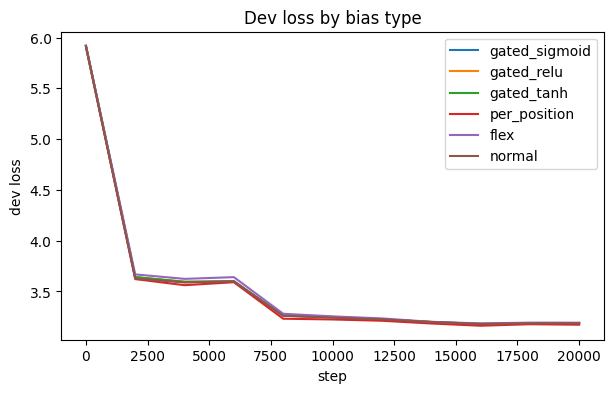


Sample continuations per model:

--- gated_sigmoid ---
  ROMEO: O party such a pracored spityest arccuslit to hon,
My ome migh, for talselks to some!
So mord that a mornow ue jeinf
her our gid of my ce, fortion,
It aga ok.

CEROMEd:
Was the canneys sues;
For to be his: Citilify, or to ISue fal, is poviols, hriem had this norrow?

TABYCAIUS:
'dack your grace.

First Duke of Bly thou k

--- gated_relu ---
  ROMEO: O:
At tongups that gad his furn
As the lace of umon' is my kingda to the ceason;
Which thery love the toop,
And what shall noble tie'dan is thride;
Who not wornrin; and in seher gie.

KING RICHARD II:
Aw; but three, blandea.

ESANORTAU:
But I cruet their youth,
But booliflsecup.
Which you cenought have s'my tron my headen live ain the remo-mor

--- gated_tanh ---
  ROMEO: thety, canontey
How of Forthere you shat:
Let ause pross.

SICINIUS:
Halady!' now I will not it ispose that mprest thou soy
Speason muds I kidshed lan you.

RaVo:
To fill theder of wordlander;
And seet come o

In [20]:
print(f"{'bias type':15s} {'params':>10s} {'final dev loss':>15s}")
for name, model in trained_models.items():
    n_params = sum(p.numel() for p in model.parameters())
    final_dev = histories[name]["dev_loss"][-1]
    print(f"{name:15s} {n_params:>10,d} {final_dev:>15.3f}")

plt.figure(figsize=(7, 4))
for name, h in histories.items():
    plt.plot(h["step"], h["dev_loss"], label=name)
plt.xlabel("step"); plt.ylabel("dev loss"); plt.legend(); plt.title("Dev loss by bias type")
plt.show()

print("\nSample continuations per model:")
for name, model in trained_models.items():
    print(f"\n--- {name} ---")
    print(generate(model, prompt="ROMEO:", length=200))


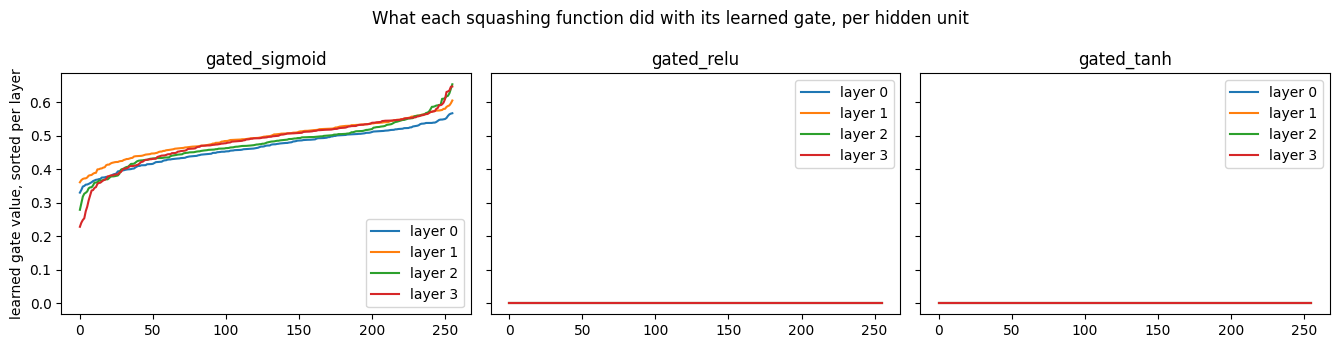

In [21]:
# What did the three gated variants actually learn to do with their gate?
gate_fns = {"gated_sigmoid": torch.sigmoid, "gated_relu": torch.relu, "gated_tanh": torch.tanh}
available = [n for n in gate_fns if n in trained_models]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(4.5 * len(available), 3.5), sharey=True)
    axes = [axes] if len(available) == 1 else axes
    for ax, name in zip(axes, available):
        model = trained_models[name]
        fn = gate_fns[name]
        for i, layer in enumerate(model.layers):
            gate_values = fn(layer.gate_param).detach().cpu().numpy()
            ax.plot(sorted(gate_values), label=f"layer {i}")
        ax.set_title(name)
        ax.legend()
    axes[0].set_ylabel("learned gate value, sorted per layer")
    plt.suptitle("What each squashing function did with its learned gate, per hidden unit")
    plt.tight_layout()
    plt.show()
else:
    print("No gated variants in trained_models -- run those sections first.")


bias type           params  final dev loss
gated_sigmoid    1,016,192           3.185
gated_relu       1,016,192           3.189
gated_tanh       1,016,192           3.189
per_position     1,022,336           3.172
flex             1,014,960           3.192
normal           1,015,168           3.187


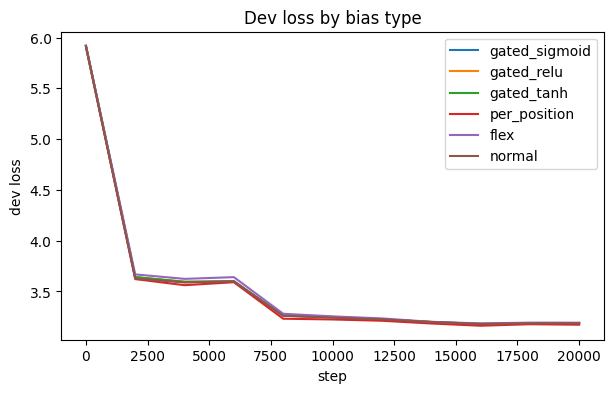


Sample names per model:


TypeError: generate() got an unexpected keyword argument 'n'

In [22]:
print(f"{'bias type':15s} {'params':>10s} {'final dev loss':>15s}")
for name, model in trained_models.items():
    n_params = sum(p.numel() for p in model.parameters())
    final_dev = histories[name]["dev_loss"][-1]
    print(f"{name:15s} {n_params:>10,d} {final_dev:>15.3f}")

plt.figure(figsize=(7, 4))
for name, h in histories.items():
    plt.plot(h["step"], h["dev_loss"], label=name)
plt.xlabel("step"); plt.ylabel("dev loss"); plt.legend(); plt.title("Dev loss by bias type")
plt.show()

print("\nSample names per model:")
for name, model in trained_models.items():
    print(f"  {name:15s}: {generate(model, n=5)}")